# Imports & Setup

In [2]:
%cd /content/drive/MyDrive/Colab\ Notebooks/transformer

/content/drive/MyDrive/Colab Notebooks/transformer


In [3]:
import os
import sys
import time
import math
import json
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import clear_output

from config import cfg, validate_config
from transformer import build_transformer
from loss import LabelSmoothingLoss
from optimizer import build_optimizer
from dataset import build_dataloaders
from train import train_epoch, validate_epoch, save_checkpoint, load_checkpoint

# Quick sanity check
validate_config(cfg)
print(f"\nDevice: {cfg.device}")
print(f"d_model={cfg.d_model}, n_heads={cfg.n_heads}, n_layers={cfg.n_layers}")
print(f"vocab_size={cfg.vocab_size}, max_seq_len={cfg.max_seq_len}")
print(f"batch_size={cfg.batch_size}, warmup_steps={cfg.warmup_steps}")

[Config] Validated. d_model=512, n_heads=8, d_k=64, n_layers=6, d_ff=2048
[Config] Device: cuda

Device: cuda
d_model=512, n_heads=8, n_layers=6
vocab_size=37000, max_seq_len=128
batch_size=32, warmup_steps=2000


# Checkpoint & History Utilities

In [4]:
CHECKPOINT_DIR = "./checkpoints"
HISTORY_PATH   = "./checkpoints/history.json"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [5]:
def save_history(history: dict, path: str = HISTORY_PATH):
    with open(path, "w") as f:
        json.dump(history, f, indent=2)

def load_history(path: str = HISTORY_PATH) -> dict:
    empty = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": [], "epoch": []}
    if os.path.exists(path):
        with open(path) as f:
            h = json.load(f)
        # back-fill epoch key if loading an old history file that lacks it
        if "epoch" not in h:
            h["epoch"] = list(range(1, len(h["train_loss"]) + 1))
        print(f"[History] Loaded {len(h['train_loss'])} epochs from {path}")
        return h
    return empty

def print_history_summary(history: dict):
    n = len(history["train_loss"])
    if n == 0:
        print("No training history yet.")
        return
    print(f"\n{'='*80}")
    print(f"{'FULL TRAINING HISTORY':^80}")
    print(f"{'='*80}")
    print(f"  {'Epoch':>6}  {'Train Loss':>10}  {'Val Loss':>10}  "
          f"{'Train Acc':>10}  {'Val Acc':>10}  {'LR':>12}")
    print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*12}")
    for i in range(n):
        ep = history["epoch"][i] if "epoch" in history else i + 1
        print(f"  {ep:>6}  {history['train_loss'][i]:>10.4f}  {history['val_loss'][i]:>10.4f}  "
              f"  {history['train_acc'][i]:>9.2%}  {history['val_acc'][i]:>9.2%}  "
              f"{history['lr'][i]:>12.2e}")
    best_ep_idx = history["val_loss"].index(min(history["val_loss"]))
    best_ep     = history["epoch"][best_ep_idx] if "epoch" in history else best_ep_idx + 1
    print(f"\n  Best val loss: {min(history['val_loss']):.4f}  at epoch {best_ep}")
    print(f"{'='*80}")

def list_checkpoints(checkpoint_dir: str = CHECKPOINT_DIR):
    files = sorted([f for f in os.listdir(checkpoint_dir) if f.endswith(".pt")])
    if not files:
        print("No checkpoints found.")
        return
    print(f"\nCheckpoints in '{checkpoint_dir}':")
    for f in files:
        path = os.path.join(checkpoint_dir, f)
        size_mb = os.path.getsize(path) / 1e6
        print(f"  {f:<30}  {size_mb:.1f} MB")

list_checkpoints()


Checkpoints in './checkpoints':
  best_model.pt                   757.8 MB
  epoch_0005.pt                   757.8 MB
  epoch_0010.pt                   757.8 MB
  epoch_0015.pt                   757.8 MB
  epoch_0020.pt                   757.8 MB
  epoch_0025.pt                   757.8 MB
  epoch_0030.pt                   757.8 MB
  latest.pt                       757.8 MB


# Plot Utilities

In [6]:
def plot_history(history: dict, save_path: str = "./checkpoints/training_curves.png"):
    n = len(history["train_loss"])
    if n == 0:
        print("Nothing to plot yet.")
        return

    epochs = history["epoch"] if "epoch" in history else list(range(1, n + 1))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
    axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="tomato")
    best_idx = history["val_loss"].index(min(history["val_loss"]))
    axes[0].axvline(epochs[best_idx], color="green", linestyle="--", alpha=0.6,
                    label=f"Best={min(history['val_loss']):.4f}")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, [a * 100 for a in history["train_acc"]], label="Train Acc", color="steelblue")
    axes[1].plot(epochs, [a * 100 for a in history["val_acc"]],   label="Val Acc",   color="tomato")
    axes[1].set_title("Token Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Learning Rate
    axes[2].plot(epochs, history["lr"], color="purple")
    axes[2].set_title("Learning Rate (Noam Schedule)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("LR")
    axes[2].grid(alpha=0.3)

    plt.suptitle(f"Training Curves — {n} epochs total", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"[Plot] Saved to {save_path}")

# Build Dataloaders

In [7]:
# It just reads the files that we already saved in Notebook 00.

train_loader, val_loader = build_dataloaders(
    train_path    = "data/train.jsonl",
    val_path      = "data/val.jsonl",
    tokenizer_path= "bpe_tokenizer.json",
    batch_size    = cfg.batch_size,
    num_workers   = 2,
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

[Dataset] Train: 21,863 samples | Val: 1,297 samples | Batch size: 32

Train batches: 684
Val   batches: 41


# Core Training Function

In [8]:
def run_training(
    num_epochs: int,
    resume_from: str = None,
    checkpoint_dir: str = CHECKPOINT_DIR,
    save_every_n_epochs: int = 5,
    verbose: bool = True,
):
    """
    Train (or continue training) the Transformer.

    Parameters
    ----------
    num_epochs      : How many MORE epochs to train from the resume point.
    resume_from     : Path to a .pt checkpoint, OR "best" / "latest" shortcuts.
                      None = start from scratch.
    checkpoint_dir  : Where to save checkpoints.
    save_every_n_epochs : Save a dated snapshot every N epochs (on top of best_model).
    verbose         : Print per-epoch row.

    Returns
    -------
    model, history
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    device = cfg.device

    # Resolve shortcut paths
    if resume_from == "best":
        resume_from = os.path.join(checkpoint_dir, "best_model.pt")
    elif resume_from == "latest":
        resume_from = os.path.join(checkpoint_dir, "latest.pt")

    # Build model + optimizer
    model = build_transformer(cfg).to(device)
    criterion = LabelSmoothingLoss(
        vocab_size     = cfg.vocab_size,
        pad_idx        = cfg.PAD_IDX,
        label_smoothing= cfg.label_smoothing,
    )
    optimizer, scheduler = build_optimizer(model, cfg)

    # Load checkpoint (if resuming)
    start_epoch = 0
    history     = load_history()   # always load from disk so history is cumulative

    if resume_from and os.path.exists(resume_from):
        loaded_epoch, ckpt_history, _ = load_checkpoint(
            resume_from, model, optimizer, scheduler
        )
        start_epoch = loaded_epoch
        # If disk history is longer/richer than what's in the checkpoint, keep disk version
        if len(history["train_loss"]) < len(ckpt_history["train_loss"]):
            history = ckpt_history
        print(f"[Resume] Continuing from epoch {start_epoch}  "
              f"(history has {len(history['train_loss'])} epochs)")
    elif resume_from:
        print(f"[Warning] Checkpoint not found: {resume_from}  — starting fresh.")

    best_val_loss = min(history["val_loss"]) if history["val_loss"] else float("inf")

    # Header
    end_epoch = start_epoch + num_epochs
    print(f"\n{'='*80}")
    print(f"  TRAINING  |  epochs {start_epoch+1} -> {end_epoch}  |  device: {device}")
    print(f"  batch={cfg.batch_size}  warmup={cfg.warmup_steps}  "
          f"d_model={cfg.d_model}  n_layers={cfg.n_layers}")
    print(f"  Params: {model.count_parameters():,}")
    print(f"{'='*80}")
    print(f"\n  {'Epoch':>6}  {'Train Loss':>10}  {'Val Loss':>10}  "
          f"{'Train Acc':>10}  {'Val Acc':>10}  {'LR':>12}  {'Time':>8}  {'Flag':>6}")
    print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*12}  {'-'*8}  {'-'*6}")

    # Epoch loop
    for epoch in range(start_epoch + 1, end_epoch + 1):
        t0 = time.time()

        train_metrics = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
        val_metrics   = validate_epoch(model, val_loader, criterion, device)

        elapsed = time.time() - t0
        flag    = ""

        # Append to history
        history["epoch"].append(epoch)
        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["lr"].append(train_metrics["lr"])

        # Save best model
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            save_checkpoint(model, optimizer, scheduler, epoch,
                            val_metrics["loss"], history,
                            os.path.join(checkpoint_dir, "best_model.pt"))
            flag = "best"

        # Periodic snapshot
        if epoch % save_every_n_epochs == 0:
            snap_path = os.path.join(checkpoint_dir, f"epoch_{epoch:04d}.pt")
            save_checkpoint(model, optimizer, scheduler, epoch,
                            val_metrics["loss"], history, snap_path)
            if not flag:
                flag = "saved"

        # Always persist latest (so Colab crash recovery is just "latest")
        save_checkpoint(model, optimizer, scheduler, epoch,
                        val_metrics["loss"], history,
                        os.path.join(checkpoint_dir, "latest.pt"))

        # Always save history JSON to disk
        save_history(history)

        if verbose:
            print(f"  {epoch:>6}  {train_metrics['loss']:>10.4f}  {val_metrics['loss']:>10.4f}  "
                  f"  {train_metrics['accuracy']:>9.2%}  {val_metrics['accuracy']:>9.2%}  "
                  f"{train_metrics['lr']:>12.2e}  {elapsed:>6.1f}s  {flag}")

    # Final summary
    print(f"\n{'='*80}")
    print(f"  Done. Trained epochs {start_epoch+1}–{end_epoch}.  "
          f"Best val loss so far: {best_val_loss:.4f}")
    print(f"{'='*80}")

    return model, history

# Training from Scratch (first run)

In [ ]:
model, history = run_training(
    num_epochs          = 5,
    resume_from         = None,   # None = fresh start
    save_every_n_epochs = 5
)

[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048

  TRAINING  |  epochs 1 -> 5  |  device: cuda
  batch=32  warmup=2000  d_model=512  n_layers=6
  Params: 63,082,496

   Epoch  Train Loss    Val Loss   Train Acc     Val Acc            LR      Time    Flag
  ------  ----------  ----------  ----------  ----------  ------------  --------  ------
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./checkpoints/latest.pt
       1      8.2029      7.3476        8.52%     11.05%      1.69e-04   320.7s  best
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./checkpoints/latest.pt
       2      7.1259      6.9894       12.48%     12.70%      3.38e-04   327.5s  best
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./checkpoints/latest.pt
       3      6.8654      6.8010       13.31%     13.57%      4.88e-04   323.7s  best
  [Checkpoint] Saved to ./checkpoin

In [ ]:
# "latest" picks the most recently saved epoch automatically.

model, history = run_training(
    num_epochs          = 5,
    resume_from         = "latest",
    save_every_n_epochs = 5,
)

[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048
[History] Loaded 5 epochs from ./checkpoints/history.json
  [Checkpoint] Loaded from ./checkpoints/latest.pt (epoch 5, val_loss 6.5767)
[Resume] Continuing from epoch 5  (history has 5 epochs)

  TRAINING  |  epochs 6 -> 10  |  device: cuda
  batch=32  warmup=2000  d_model=512  n_layers=6
  Params: 63,082,496

   Epoch  Train Loss    Val Loss   Train Acc     Val Acc            LR      Time    Flag
  ------  ----------  ----------  ----------  ----------  ------------  --------  ------
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./checkpoints/latest.pt
       6      6.4618      6.5153       14.98%     14.46%      3.45e-04   277.2s  best
  [Checkpoint] Saved to ./checkpoints/latest.pt
       7      6.3801      6.5294       15.46%     13.73%      3.19e-04   282.1s  
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./check

In [ ]:
# "latest" picks the most recently saved epoch automatically.

model, history = run_training(
    num_epochs          = 5,
    resume_from         = "latest",
    save_every_n_epochs = 5,
)

[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048
[History] Loaded 10 epochs from ./checkpoints/history.json
  [Checkpoint] Loaded from ./checkpoints/latest.pt (epoch 10, val_loss 6.3946)
[Resume] Continuing from epoch 10  (history has 10 epochs)

  TRAINING  |  epochs 11 -> 15  |  device: cuda
  batch=32  warmup=2000  d_model=512  n_layers=6
  Params: 63,082,496

   Epoch  Train Loss    Val Loss   Train Acc     Val Acc            LR      Time    Flag
  ------  ----------  ----------  ----------  ----------  ------------  --------  ------
  [Checkpoint] Saved to ./checkpoints/latest.pt
      11      6.1167      6.4009       17.00%     14.56%      2.55e-04   278.1s  
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./checkpoints/latest.pt
      12      6.0679      6.3761       17.32%     14.65%      2.44e-04   278.0s  best
  [Checkpoint] Saved to ./checkpoints/latest.pt
      13      6.0271      6.38

[History] Loaded 15 epochs from ./checkpoints/history.json

                             FULL TRAINING HISTORY                              
   Epoch  Train Loss    Val Loss   Train Acc     Val Acc            LR
  ------  ----------  ----------  ----------  ----------  ------------
       1      8.2029      7.3476        8.52%     11.05%      1.69e-04
       2      7.1259      6.9894       12.48%     12.70%      3.38e-04
       3      6.8654      6.8010       13.31%     13.57%      4.88e-04
       4      6.6915      6.6453       13.82%     14.11%      4.22e-04
       5      6.5580      6.5767       14.46%     14.30%      3.78e-04
       6      6.4618      6.5153       14.98%     14.46%      3.45e-04
       7      6.3801      6.5294       15.46%     13.73%      3.19e-04
       8      6.3054      6.4708       15.89%     14.42%      2.99e-04
       9      6.2359      6.4818       16.34%     13.68%      2.82e-04
      10      6.1753      6.3946       16.65%     14.80%      2.67e-04
      1

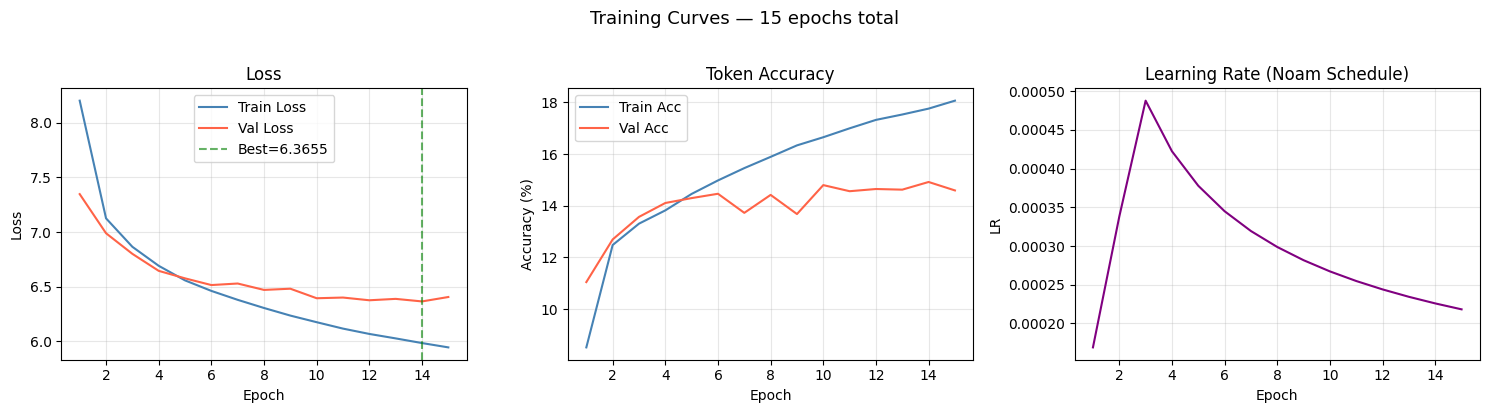

[Plot] Saved to ./checkpoints/training_curves.png


In [ ]:
# Load history from disk (works even if model isn't loaded in memory)
history = load_history()

# Pretty-print table
print_history_summary(history)

# Plot all three curves
plot_history(history)

In [ ]:
# "latest" picks the most recently saved epoch automatically.

model, history = run_training(
    num_epochs          = 5,
    resume_from         = "latest",
    save_every_n_epochs = 5,
)

[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048
[History] Loaded 15 epochs from ./checkpoints/history.json
  [Checkpoint] Loaded from ./checkpoints/latest.pt (epoch 15, val_loss 6.4059)
[Resume] Continuing from epoch 15  (history has 15 epochs)

  TRAINING  |  epochs 16 -> 20  |  device: cuda
  batch=32  warmup=2000  d_model=512  n_layers=6
  Params: 63,082,496

   Epoch  Train Loss    Val Loss   Train Acc     Val Acc            LR      Time    Flag
  ------  ----------  ----------  ----------  ----------  ------------  --------  ------
  [Checkpoint] Saved to ./checkpoints/latest.pt
      16      5.9087      6.3903       18.26%     14.60%      2.11e-04   280.4s  
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./checkpoints/latest.pt
      17      5.8717      6.3061       18.47%     15.42%      2.05e-04   279.9s  best
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./

In [ ]:
# "latest" picks the most recently saved epoch automatically.

model, history = run_training(
    num_epochs          = 5,
    resume_from         = "latest",
    save_every_n_epochs = 5,
)

[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048
[History] Loaded 20 epochs from ./checkpoints/history.json
  [Checkpoint] Loaded from ./checkpoints/latest.pt (epoch 20, val_loss 6.3739)
[Resume] Continuing from epoch 20  (history has 20 epochs)

  TRAINING  |  epochs 21 -> 25  |  device: cuda
  batch=32  warmup=2000  d_model=512  n_layers=6
  Params: 63,082,496

   Epoch  Train Loss    Val Loss   Train Acc     Val Acc            LR      Time    Flag
  ------  ----------  ----------  ----------  ----------  ------------  --------  ------
  [Checkpoint] Saved to ./checkpoints/latest.pt
      21      5.7485      6.3315       19.23%     15.59%      1.84e-04   287.1s  
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./checkpoints/latest.pt
      22      5.7202      6.2925       19.43%     16.04%      1.80e-04   304.7s  best
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./

In [ ]:
# "latest" picks the most recently saved epoch automatically.

model, history = run_training(
    num_epochs          = 5,
    resume_from         = "latest",
    save_every_n_epochs = 5,
)

[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048
[History] Loaded 25 epochs from ./checkpoints/history.json
  [Checkpoint] Loaded from ./checkpoints/latest.pt (epoch 25, val_loss 6.3084)
[Resume] Continuing from epoch 25  (history has 25 epochs)

  TRAINING  |  epochs 26 -> 30  |  device: cuda
  batch=32  warmup=2000  d_model=512  n_layers=6
  Params: 63,082,496

   Epoch  Train Loss    Val Loss   Train Acc     Val Acc            LR      Time    Flag
  ------  ----------  ----------  ----------  ----------  ------------  --------  ------
  [Checkpoint] Saved to ./checkpoints/latest.pt
      26      5.6214      6.3093       20.02%     15.91%      1.66e-04   303.3s  
  [Checkpoint] Saved to ./checkpoints/latest.pt
      27      5.5966      6.3020       20.20%     16.43%      1.63e-04   303.8s  
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./checkpoints/latest.pt
      28      5.5745      6.2640  

In [9]:
# "latest" picks the most recently saved epoch automatically.

model, history = run_training(
    num_epochs          = 5,
    resume_from         = "latest",
    save_every_n_epochs = 5,
)

[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048
[History] Loaded 30 epochs from ./checkpoints/history.json
  [Checkpoint] Loaded from ./checkpoints/latest.pt (epoch 30, val_loss 6.2721)
[Resume] Continuing from epoch 30  (history has 30 epochs)

  TRAINING  |  epochs 31 -> 35  |  device: cuda
  batch=32  warmup=2000  d_model=512  n_layers=6
  Params: 63,082,496

   Epoch  Train Loss    Val Loss   Train Acc     Val Acc            LR      Time    Flag
  ------  ----------  ----------  ----------  ----------  ------------  --------  ------
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./checkpoints/latest.pt
      31      5.5111      6.2604       20.72%     16.91%      1.52e-04   312.1s  best
  [Checkpoint] Saved to ./checkpoints/best_model.pt
  [Checkpoint] Saved to ./checkpoints/latest.pt
      32      5.4896      6.2494       20.81%     17.15%      1.49e-04   324.3s  best
  [Checkpoint] Saved t

[History] Loaded 35 epochs from ./checkpoints/history.json

                             FULL TRAINING HISTORY                              
   Epoch  Train Loss    Val Loss   Train Acc     Val Acc            LR
  ------  ----------  ----------  ----------  ----------  ------------
       1      8.2029      7.3476        8.52%     11.05%      1.69e-04
       2      7.1259      6.9894       12.48%     12.70%      3.38e-04
       3      6.8654      6.8010       13.31%     13.57%      4.88e-04
       4      6.6915      6.6453       13.82%     14.11%      4.22e-04
       5      6.5580      6.5767       14.46%     14.30%      3.78e-04
       6      6.4618      6.5153       14.98%     14.46%      3.45e-04
       7      6.3801      6.5294       15.46%     13.73%      3.19e-04
       8      6.3054      6.4708       15.89%     14.42%      2.99e-04
       9      6.2359      6.4818       16.34%     13.68%      2.82e-04
      10      6.1753      6.3946       16.65%     14.80%      2.67e-04
      1

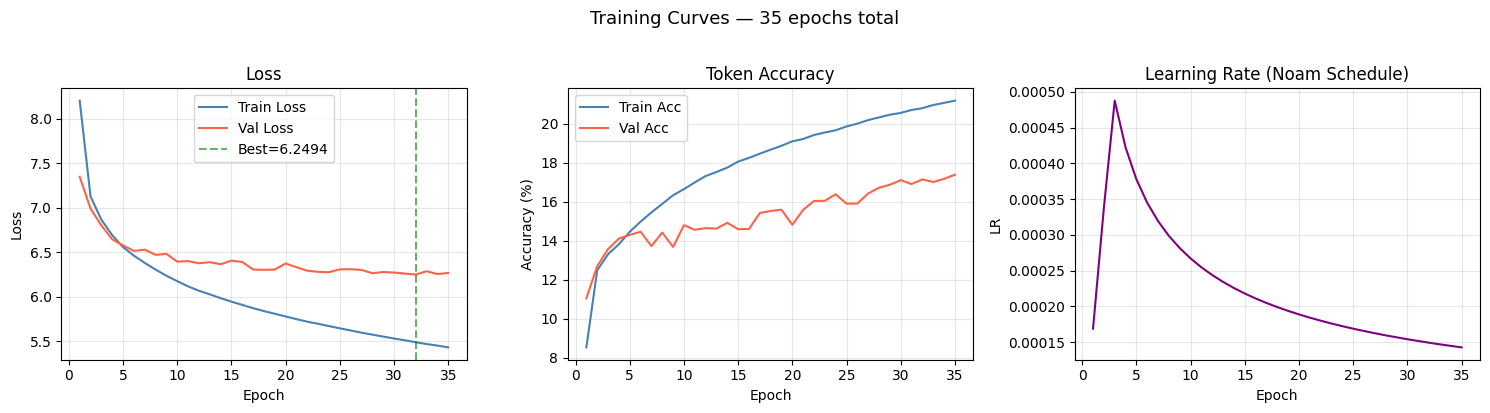

[Plot] Saved to ./checkpoints/training_curves.png


In [13]:
# Load history from disk (works even if model isn't loaded in memory)
history = load_history()

# Pretty-print table
print_history_summary(history)

# Plot all three curves
plot_history(history)